 ════════════════════════════════════════════════════════
# PHASE 2  : Isolation Forest NON-SUPERVISÉ
 ════════════════════════════════════════════════════════


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, f1_score, recall_score, precision_score
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 130
print('OK ✓')

OK ✓


# 1. CHARGEMENT
 On charge `features_ml.csv`  . On garde `is_anomaly` à part, simplement pour l'évaluation finale

In [ ]:
features_df = pd.read_csv('../data/features_ml.csv')

# y_true : UNIQUEMENT pour évaluer, jamais pour entraîner
y_true = features_df['is_anomaly']

# X : toutes les colonnes numériques sauf métadonnées et label
EXCLUDE_COLS = [
    'server_id', 'timestamp', 'is_anomaly', 'anomaly_type',
    # Colonnes dérivées de l'AE — data leakage, absentes en production
    'dist_to_threshold', 'label_3class', 'is_anomaly_clean'
]

FEATURES_ML = [
    col for col in features_df.columns
    if col not in EXCLUDE_COLS
    and features_df[col].dtype in ['float64', 'int64', 'float32', 'int32']
]
X_raw = features_df[FEATURES_ML].fillna(0)

print(f'Shape X       : {X_raw.shape}')
print(f'Nb features   : {len(FEATURES_ML)}')
print(f'Anomalies réelles (pour info, non utilisées à l\'entraînement) : {y_true.sum()} ({y_true.mean()*100:.1f}%)')
print(f'\nListe des features :')
print(FEATURES_ML)

Shape X       : (4443, 46)
Nb features   : 46
Anomalies réelles (pour info, non utilisées à l'entraînement) : 194 (4.4%)

Liste des features :
['request_count', 'unique_ips', 'avg_response_time', 'median_response_time', 'p95_response_time', 'p99_response_time', 'max_response_time', 'std_response_time', 'error_rate_5xx', 'error_rate_4xx', 'success_rate', 'avg_bytes_sent', 'total_bytes_sent', 'bot_ratio', 'mobile_ratio', 'desktop_ratio', 'api_ratio', 'static_ratio', 'auth_ratio', 'get_ratio', 'post_ratio', 'hour', 'is_weekend', 'is_business_hours', 'response_time_change', 'request_count_change', 'error_rate_change', 'rolling_avg_response', 'response_vs_rolling', 'stress_score', 'quality_degradation', 'latency_spike', 'error_severity_ratio', 'response_cv', 'load_pressure', 'log_avg_response', 'log_p99_response', 'log_std_response', 'log_load_pressure', 'response_vs_rolling_abs', 'response_zscore_per_server', 'severity_latency', 'severity_error', 'severity_traffic', 'max_severity', 'combin

# 2. STANDARDISATION 


In [34]:
# Split temporel : pas de mélange passé/futur (même logique que le notebook Autoencoder)
features_df_sorted = features_df.sort_values('timestamp').reset_index(drop=True)
X_raw_sorted = features_df_sorted[FEATURES_ML].fillna(0)
y_true_sorted = features_df_sorted['is_anomaly']

n = len(X_raw_sorted)
test_start = int(n * 0.80)

X_train_raw = X_raw_sorted.iloc[:test_start].reset_index(drop=True)
X_test_raw  = X_raw_sorted.iloc[test_start:].reset_index(drop=True)
y_train_true = y_true_sorted.iloc[:test_start].reset_index(drop=True)
y_test_true  = y_true_sorted.iloc[test_start:].reset_index(drop=True)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)  # fit uniquement sur train
X_test  = scaler.transform(X_test_raw)
import pickle
with open("../data/isolation_forest_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
print("✅ isolation_forest_scaler.pkl sauvegardé")
print(f'Split temporel appliqué (80% ancien / 20% récent)')
print(f'Train : {X_train.shape[0]} lignes')
print(f'Test  : {X_test.shape[0]} lignes')
print(f'Anomalies in test : {y_test_true.sum()} ({y_test_true.mean()*100:.1f}%)')

✅ isolation_forest_scaler.pkl sauvegardé
Split temporel appliqué (80% ancien / 20% récent)
Train : 3554 lignes
Test  : 889 lignes
Anomalies in test : 34 (3.8%)


# 3. ENTRAÎNEMENT NON-SUPERVISÉ — recherche d'hyperparamètres
La contamination est un hyperparamètre de PROPORTION attendue d'anomalies,


In [4]:
# Clipping ciblé uniquement sur la colonne buggée (identique au notebook Autoencoder)
COLS_TO_CLIP = ["quality_degradation"]

def clip_specific_columns(df, columns, lower_q=0.01, upper_q=0.99, bounds=None):
    df_clipped = df.copy()
    if bounds is None:
        bounds = {}
        for col in columns:
            low  = df[col].quantile(lower_q)
            high = df[col].quantile(upper_q)
            bounds[col] = (low, high)
    for col in columns:
        low, high = bounds[col]
        df_clipped[col] = df_clipped[col].clip(lower=low, upper=high)
    return df_clipped, bounds

X_train_raw, clip_bounds = clip_specific_columns(X_train_raw, COLS_TO_CLIP)
X_test_raw, _ = clip_specific_columns(X_test_raw, COLS_TO_CLIP, bounds=clip_bounds)

print(f"Clipping appliqué sur : {COLS_TO_CLIP}")
print(f"quality_degradation max avant clip (test) : {X_test_raw['quality_degradation'].max():.1f}")

Clipping appliqué sur : ['quality_degradation']
quality_degradation max avant clip (test) : 61200.0


In [5]:
# Grille de contamination basée sur des hypothèses métier raisonnables
contamination_grid = [0.02, 0.03, 0.05, 0.07, 0.10]
n_estimators_grid   = [100, 200, 300]

models_grid = {}
for cont in contamination_grid:
    for n_est in n_estimators_grid:
        model = IsolationForest(
            n_estimators=n_est,
            contamination=cont,
            max_samples='auto',
            random_state=42,
            n_jobs=-1
        )
        model.fit(X_train)  
        scores = -model.score_samples(X_test)
        models_grid[(cont, n_est)] = (model, scores)

print(f'{len(models_grid)} modèles entraînés (non-supervisé, label jamais utilisé)')

15 modèles entraînés (non-supervisé, label jamais utilisé)


# 4. ÉVALUATION 
(label utilisé ICI seulement, en lecture)

In [6]:
eval_rows = []
for (cont, n_est), (model, scores) in models_grid.items():
    auc = roc_auc_score(y_test_true, scores)
    ap  = average_precision_score(y_test_true, scores)
    # Seuil naturel du modèle (predict() utilise déjà la contamination interne)
    preds_native = (model.predict(X_test) == -1).astype(int)
    f1_native  = f1_score(y_test_true, preds_native, zero_division=0)
    rec_native = recall_score(y_test_true, preds_native, zero_division=0)
    pre_native = precision_score(y_test_true, preds_native, zero_division=0)
    eval_rows.append({
        'contamination': cont, 'n_estimators': n_est,
        'roc_auc': auc, 'avg_precision': ap,
        'f1_native': f1_native, 'recall_native': rec_native, 'precision_native': pre_native
    })

eval_df = pd.DataFrame(eval_rows).sort_values('roc_auc', ascending=False)
print('=== Classement par ROC-AUC (métrique indépendante du seuil) ===')
print(eval_df.to_string(index=False))

# On sélectionne le modèle final sur la base du ROC-AUC, qui ne dépend pas
# du choix de seuil — c'est la métrique la plus honnête en non-supervisé.
best_cont, best_n_est = eval_df.iloc[0][['contamination', 'n_estimators']]
best_cont = float(best_cont); best_n_est = int(best_n_est)
print(f'\n>>> Modèle retenu : contamination={best_cont}, n_estimators={best_n_est}')

=== Classement par ROC-AUC (métrique indépendante du seuil) ===
 contamination  n_estimators  roc_auc  avg_precision  f1_native  recall_native  precision_native
          0.02           200 0.986550       0.711148   0.518519       0.411765          0.700000
          0.03           200 0.986550       0.711148   0.580645       0.529412          0.642857
          0.05           200 0.986550       0.711148   0.702703       0.764706          0.650000
          0.07           200 0.986550       0.711148   0.689655       0.882353          0.566038
          0.10           200 0.986550       0.711148   0.566667       1.000000          0.395349
          0.05           100 0.986309       0.713413   0.684932       0.735294          0.641026
          0.02           100 0.986309       0.713413   0.518519       0.411765          0.700000
          0.10           100 0.986309       0.713413   0.554622       0.970588          0.388235
          0.07           100 0.986309       0.713413   0.674157

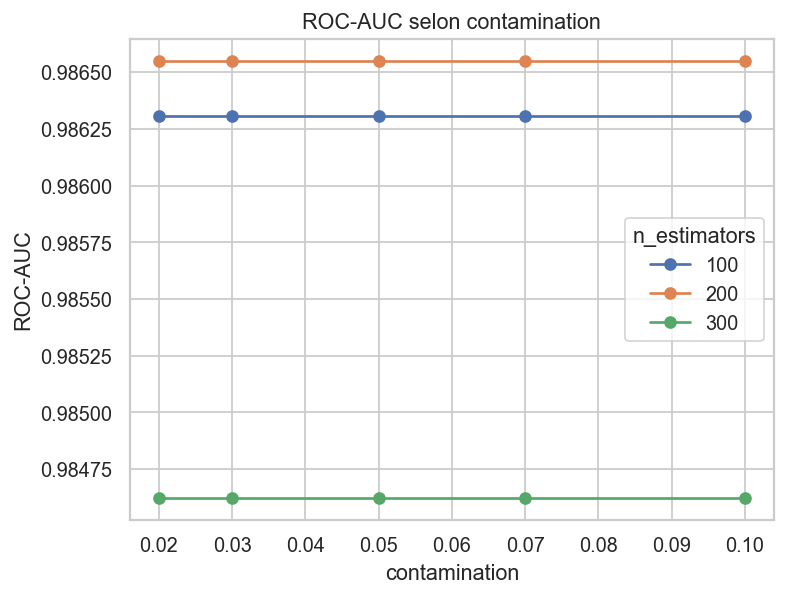

In [7]:
#Pour chaque valeur de n_estimators
import seaborn as sns
import matplotlib.pyplot as plt

pivot = eval_df.pivot(
    index='contamination',
    columns='n_estimators',
    values='roc_auc'
)

pivot.plot(marker='o')
plt.ylabel("ROC-AUC")
plt.title("ROC-AUC selon contamination")
plt.grid(True)
plt.show()

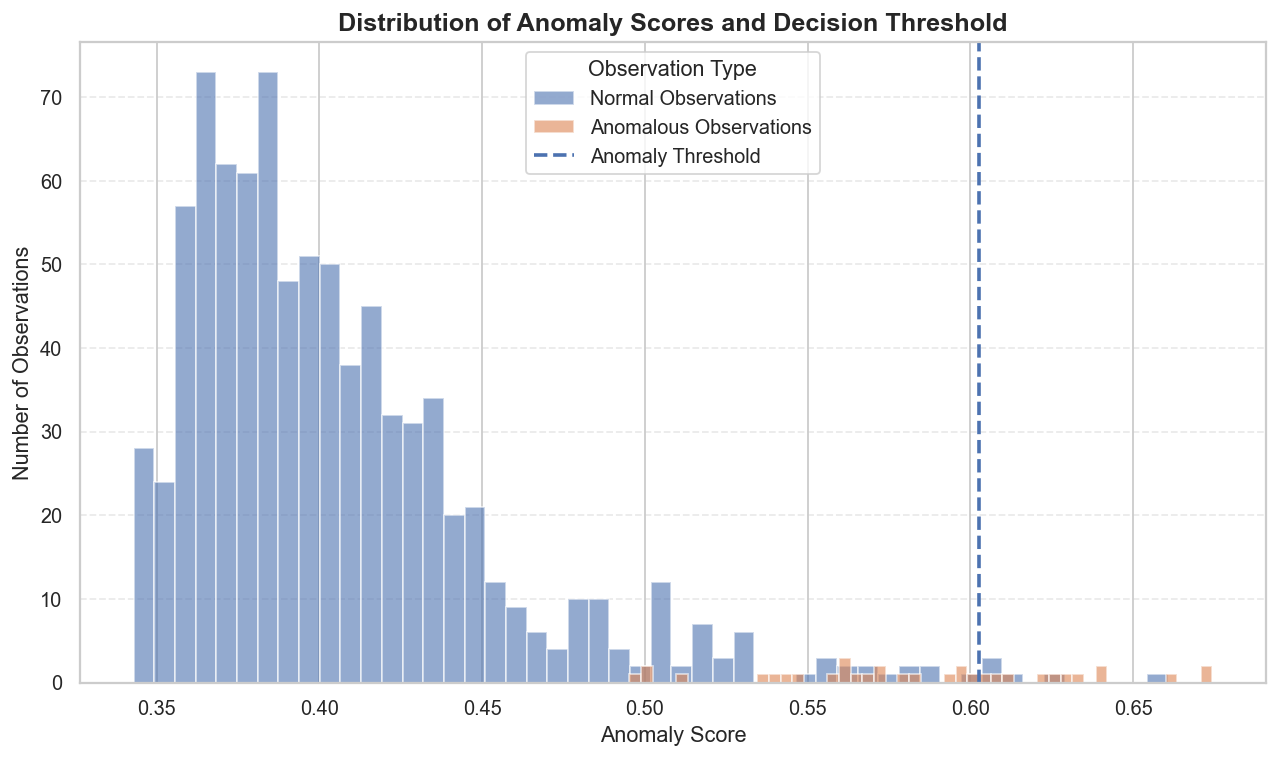

In [8]:
scores = -model.score_samples(X_test)

plt.figure(figsize=(10,6))

plt.hist(
    scores[y_test_true == 0],
    bins=50,
    alpha=0.6,
    label='Normal Observations'
)

plt.hist(
    scores[y_test_true == 1],
    bins=50,
    alpha=0.6,
    label='Anomalous Observations'
)

plt.axvline(
    np.percentile(scores, 98),  # contamination = 0.02
    linestyle='--',
    linewidth=2,
    label='Anomaly Threshold'
)

plt.title(
    'Distribution of Anomaly Scores and Decision Threshold',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    'Anomaly Score',
    fontsize=12
)

plt.ylabel(
    'Number of Observations',
    fontsize=12
)

plt.legend(title='Observation Type')
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

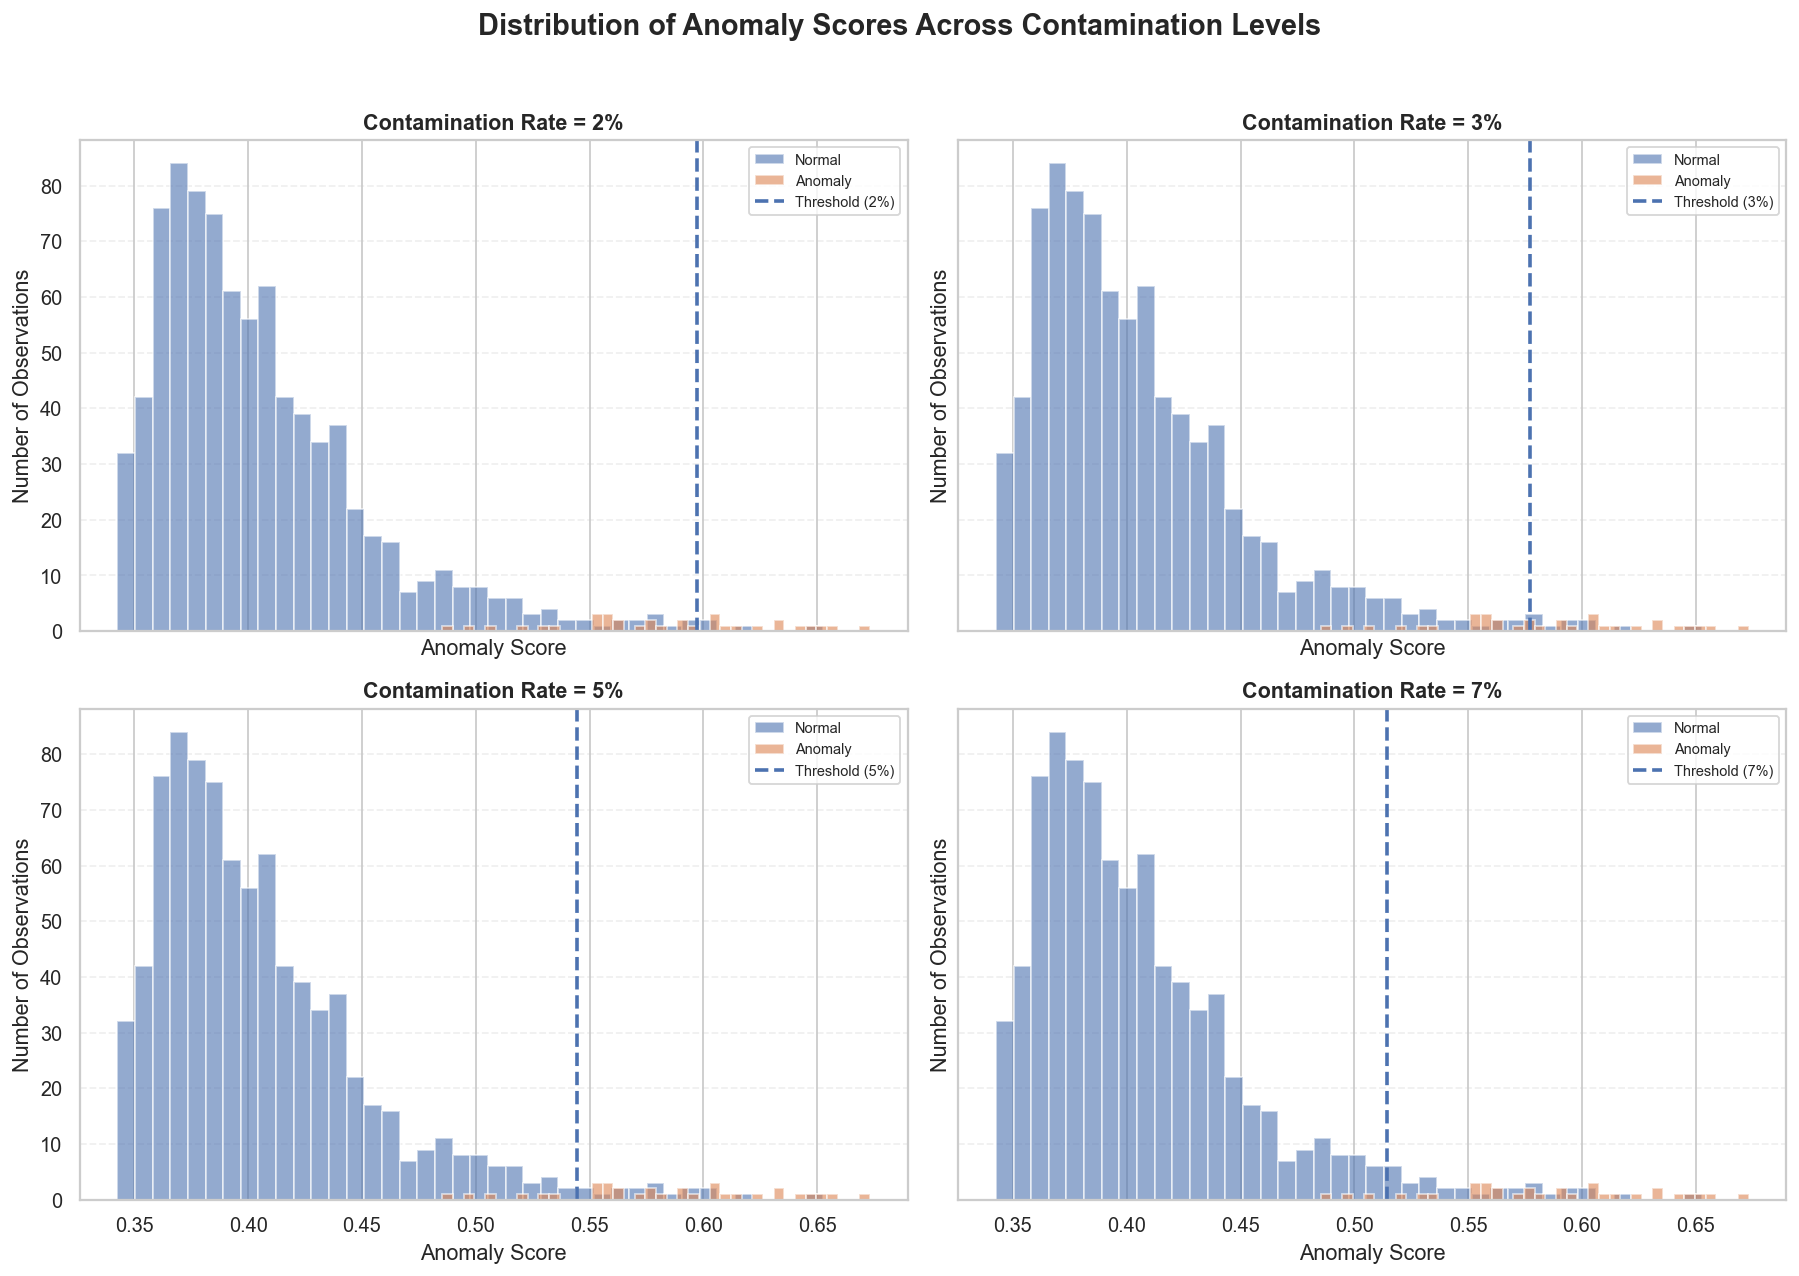

In [9]:
import matplotlib.pyplot as plt
import numpy as np

contaminations = [0.02, 0.03, 0.05, 0.07]  # suppression de 0.10
n_est = 100

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(14, 10),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for ax, cont in zip(axes, contaminations):

    model, scores = models_grid[(cont, n_est)]

    # seuil correspondant à la contamination
    threshold = np.percentile(scores, 100 * (1 - cont))

    ax.hist(
        scores[y_test_true == 0],
        bins=40,
        alpha=0.6,
        label='Normal'
    )

    ax.hist(
        scores[y_test_true == 1],
        bins=40,
        alpha=0.6,
        label='Anomaly'
    )

    ax.axvline(
        threshold,
        linestyle='--',
        linewidth=2,
        label=f'Threshold ({cont:.0%})'
    )

    ax.set_title(
        f'Contamination Rate = {cont:.0%}',
        fontsize=12,
        fontweight='bold'
    )

    ax.set_xlabel('Anomaly Score')
    ax.set_ylabel('Number of Observations')

    ax.legend(fontsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

fig.suptitle(
    'Distribution of Anomaly Scores Across Contamination Levels',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# 5. MODÈLE FINAL

In [10]:
iso_final = IsolationForest(
    n_estimators=best_n_est,
    contamination=best_cont,
    max_samples='auto',
    random_state=42,
    n_jobs=-1
)
iso_final.fit(X_train)

scores_test = -iso_final.score_samples(X_test)

print(f'ROC-AUC      : {roc_auc_score(y_test_true, scores_test):.4f}')
print(f'Avg Precision: {average_precision_score(y_test_true, scores_test):.4f}')

ROC-AUC      : 0.9865
Avg Precision: 0.7111


# 6. CHOIX DU SEUIL


In [11]:
# Sensitivity analysis : même logique que le notebook Autoencoder (sweep P80 -> P99, F1 max)
percentiles = range(80, 100)
f1_scores, precisions, recalls, thresholds_list, flag_rates = [], [], [], [], []

for pct in percentiles:
    thresh = np.percentile(scores_test, pct)
    preds  = (scores_test >= thresh).astype(int)
    f1_scores.append(f1_score(y_test_true, preds, zero_division=0))
    precisions.append(precision_score(y_test_true, preds, zero_division=0))
    recalls.append(recall_score(y_test_true, preds, zero_division=0))
    thresholds_list.append(thresh)
    flag_rates.append(preds.mean() * 100)

best_idx = int(np.argmax(f1_scores))
BEST_THRESHOLD  = thresholds_list[best_idx]
BEST_PERCENTILE = list(percentiles)[best_idx]

print("=== SENSITIVITY ANALYSIS RESULTS ===\n")
print(f"{'Pct':>4} | {'Threshold':>10} | {'F1':>6} | {'Precision':>9} | {'Recall':>6} | {'Flag%':>6}")
print("-" * 55)
for i, pct in enumerate(percentiles):
    mark = " ← BEST" if i == best_idx else ""
    print(f"  P{pct} | {thresholds_list[i]:>10.6f} | {f1_scores[i]:>6.3f} | "
          f"{precisions[i]:>9.3f} | {recalls[i]:>6.3f} | {flag_rates[i]:>5.1f}%{mark}")

THRESHOLD = BEST_THRESHOLD
y_pred = (scores_test >= THRESHOLD).astype(int)

print(f"\nSeuil retenu : {THRESHOLD:.6f} (P{BEST_PERCENTILE})")
print(classification_report(y_test_true, y_pred, target_names=['Normal', 'Anomalie'], digits=3))

=== SENSITIVITY ANALYSIS RESULTS ===

 Pct |  Threshold |     F1 | Precision | Recall |  Flag%
-------------------------------------------------------
  P80 |   0.438177 |  0.321 |     0.191 |  1.000 |  20.0%
  P81 |   0.440250 |  0.335 |     0.201 |  1.000 |  19.0%
  P82 |   0.443264 |  0.351 |     0.212 |  1.000 |  18.0%
  P83 |   0.447116 |  0.368 |     0.225 |  1.000 |  17.0%
  P84 |   0.449329 |  0.384 |     0.238 |  1.000 |  16.1%
  P85 |   0.452589 |  0.405 |     0.254 |  1.000 |  15.1%
  P86 |   0.457172 |  0.428 |     0.272 |  1.000 |  14.1%
  P87 |   0.461984 |  0.453 |     0.293 |  1.000 |  13.0%
  P88 |   0.474770 |  0.482 |     0.318 |  1.000 |  12.0%
  P89 |   0.478970 |  0.515 |     0.347 |  1.000 |  11.0%
  P90 |   0.485679 |  0.553 |     0.382 |  1.000 |  10.0%
  P91 |   0.496772 |  0.579 |     0.412 |  0.971 |   9.0%
  P92 |   0.501383 |  0.585 |     0.431 |  0.912 |   8.1%
  P93 |   0.510538 |  0.639 |     0.492 |  0.912 |   7.1%
  P94 |   0.523828 |  0.682 |     0.5

# 7. VISUALISATIONS

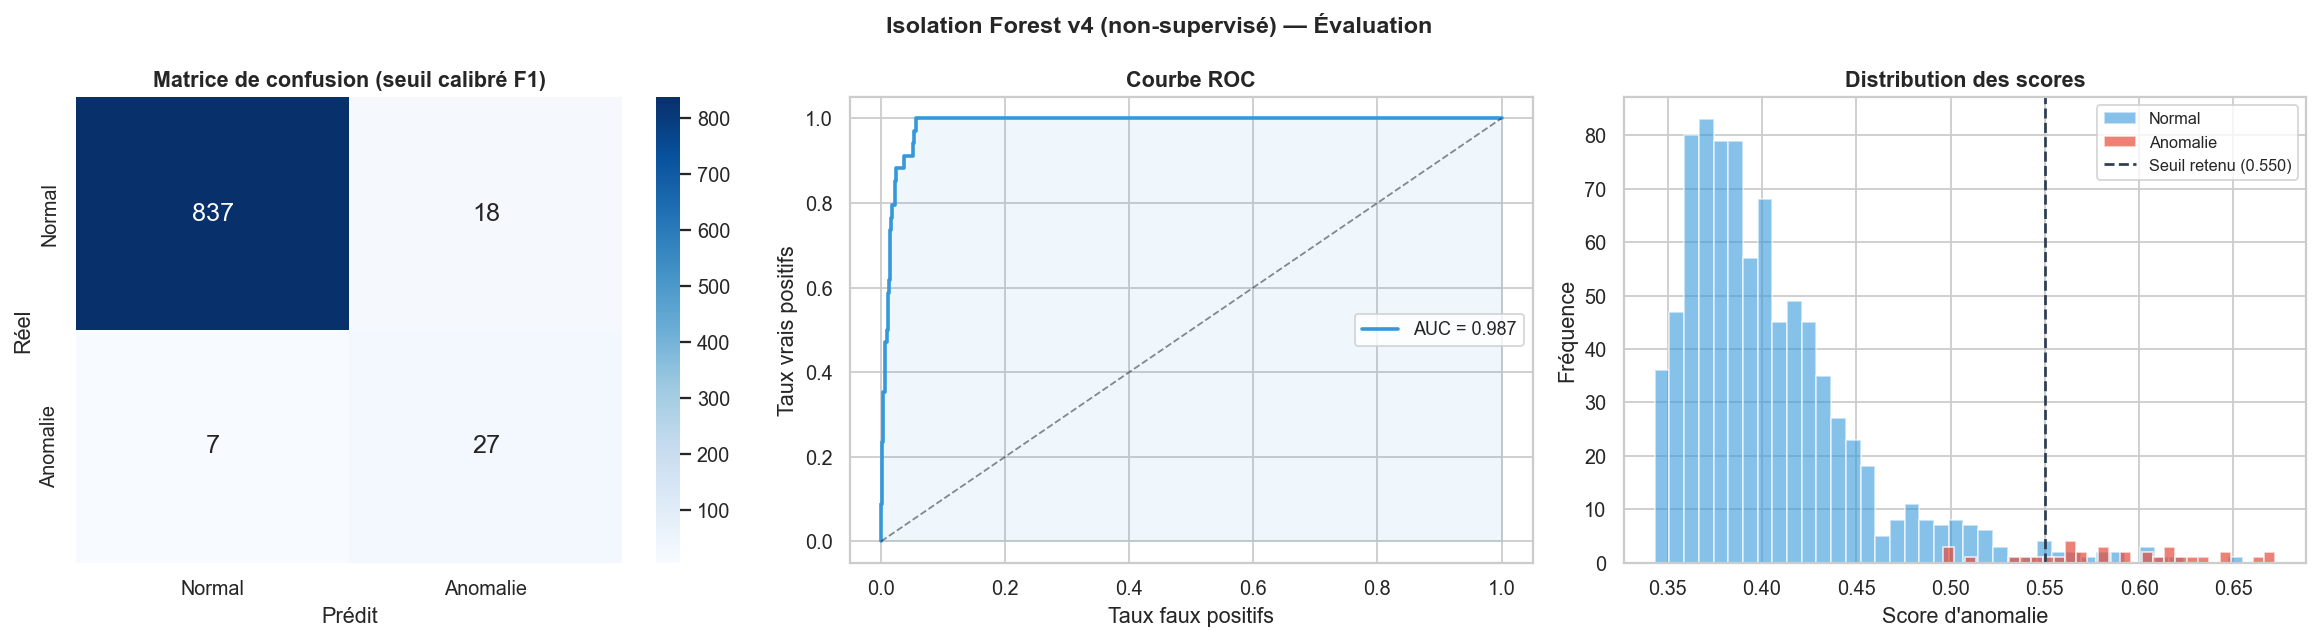

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# AFTER
cm = confusion_matrix(y_test_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomalie'], yticklabels=['Normal', 'Anomalie'],
            ax=axes[0], annot_kws={'size': 14})
axes[0].set_xlabel('Prédit'); axes[0].set_ylabel('Réel')
axes[0].set_title('Matrice de confusion (seuil calibré F1)', fontsize=12, fontweight='bold')

fpr, tpr, _ = roc_curve(y_test_true, scores_test)
roc_auc = roc_auc_score(y_test_true, scores_test)
axes[1].plot(fpr, tpr, color='#3498db', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0,1], [0,1], 'k--', lw=1, alpha=0.5)
axes[1].fill_between(fpr, tpr, alpha=0.08, color='#3498db')
axes[1].set_xlabel('Taux faux positifs'); axes[1].set_ylabel('Taux vrais positifs')
axes[1].set_title('Courbe ROC', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)

axes[2].hist(scores_test[y_test_true == 0], bins=40, alpha=0.6,
             color='#3498db', label='Normal', edgecolor='white')
axes[2].hist(scores_test[y_test_true == 1], bins=30, alpha=0.7,
             color='#e74c3c', label='Anomalie', edgecolor='white')
# AFTER
axes[2].axvline(THRESHOLD, color='#2c3e50', linestyle='--', lw=1.5, label=f'Seuil retenu ({THRESHOLD:.3f})')
axes[2].set_xlabel("Score d'anomalie"); axes[2].set_ylabel('Fréquence')
axes[2].set_title('Distribution des scores', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=9)

plt.suptitle('Isolation Forest v4 (non-supervisé) — Évaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../report/evaluation_IF_v4.png', bbox_inches='tight')
plt.show()

# 7bis. DIAGNOSTIC DES FAUX POSITIFS (point 1)


In [13]:
# On reconstruit un dataframe lisible des FP au seuil métier choisi (FINAL_THRESHOLD)
# en gardant les colonnes interprétables (non standardisées)

X_test_raw_indexed = X_test_raw.reset_index(drop=True)
y_test_true_indexed = y_test_true.reset_index(drop=True)

diag_df = X_test_raw_indexed.copy()
diag_df["y_true"] = y_test_true_indexed.values
diag_df["anomaly_score"] = scores_test
diag_df["y_pred"] = y_pred

# Faux positifs : prédit Anomalie (1) mais réellement Normal (0)
false_positives = diag_df[(diag_df["y_pred"] == 1) & (diag_df["y_true"] == 0)]
print(f"Nombre de faux positifs au seuil {THRESHOLD} : {len(false_positives)}")

cols_to_check = ["error_rate_5xx", "p95_response_time", "request_count", "anomaly_score"]
print("\n=== Statistiques des FP sur les variables clés ===")
print(false_positives[cols_to_check].describe())

# Combien de FP sont des cas "limites" (proches d'un des seuils métier, à 20% près) ?
near_error_thresh   = (false_positives["error_rate_5xx"] > 0.016).sum()    # 80% du seuil 0.02
near_latence_thresh = (false_positives["p95_response_time"] > 1200).sum()  # 80% du seuil 1500

print(f"\nFP proches du seuil error_rate_5xx (>80% du seuil) : {near_error_thresh}/{len(false_positives)}")
print(f"FP proches du seuil p95_response_time (>80% du seuil) : {near_latence_thresh}/{len(false_positives)}")

n_limite_fp = ((false_positives["error_rate_5xx"] > 0.016) |
               (false_positives["p95_response_time"] > 1200)).sum()
pct_limite = n_limite_fp / len(false_positives) * 100 if len(false_positives) > 0 else 0
print(f"\n>>> {n_limite_fp}/{len(false_positives)} FP ({pct_limite:.1f}%) sont des cas limites,")
print(f">>> proches d'un seuil métier, et non de vraies erreurs du modèle.")

Nombre de faux positifs au seuil 0.5501159828046572 : 18

=== Statistiques des FP sur les variables clés ===
       error_rate_5xx  p95_response_time  request_count  anomaly_score
count            18.0          18.000000      18.000000      18.000000
mean              0.0        1111.644444       1.277778       0.583631
std               0.0         278.200199       0.460889       0.028470
min               0.0         513.150000       1.000000       0.550635
25%               0.0         909.000000       1.000000       0.561291
50%               0.0        1164.850000       1.000000       0.579014
75%               0.0        1350.750000       1.750000       0.604502
max               0.0        1465.000000       2.000000       0.654999

FP proches du seuil error_rate_5xx (>80% du seuil) : 0/18
FP proches du seuil p95_response_time (>80% du seuil) : 9/18

>>> 9/18 FP (50.0%) sont des cas limites,
>>> proches d'un seuil métier, et non de vraies erreurs du modèle.


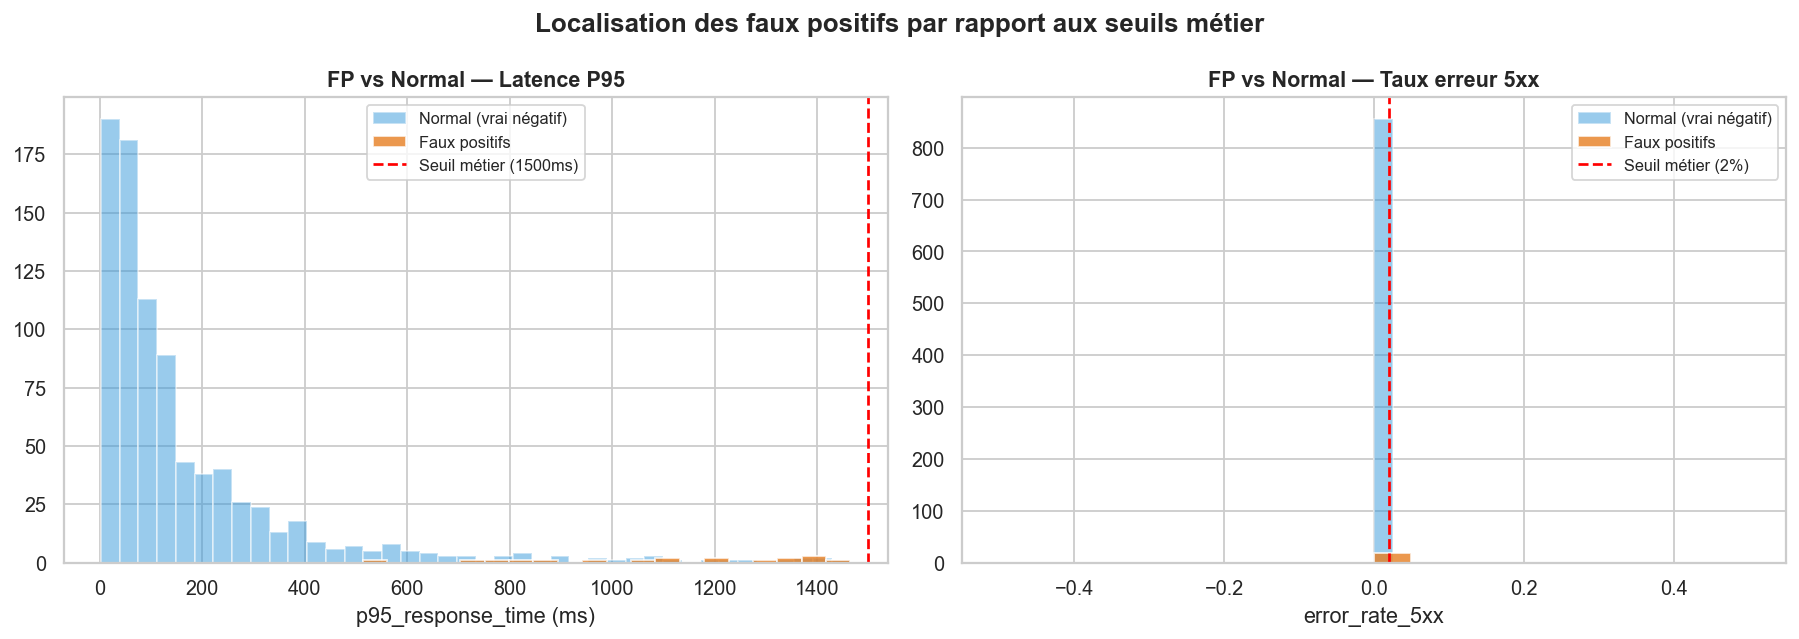

In [14]:
# Visualisation : où se situent les FP par rapport à la distribution générale ?

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(diag_df[diag_df["y_true"]==0]["p95_response_time"], bins=40,
             alpha=0.5, color="#3498db", label="Normal (vrai négatif)")
axes[0].hist(false_positives["p95_response_time"], bins=20,
             alpha=0.8, color="#e67e22", label="Faux positifs")
axes[0].axvline(1500, color="red", linestyle="--", label="Seuil métier (1500ms)")
axes[0].set_xlabel("p95_response_time (ms)")
axes[0].set_title("FP vs Normal — Latence P95", fontweight="bold")
axes[0].legend(fontsize=9)

axes[1].hist(diag_df[diag_df["y_true"]==0]["error_rate_5xx"], bins=40,
             alpha=0.5, color="#3498db", label="Normal (vrai négatif)")
axes[1].hist(false_positives["error_rate_5xx"], bins=20,
             alpha=0.8, color="#e67e22", label="Faux positifs")
axes[1].axvline(0.02, color="red", linestyle="--", label="Seuil métier (2%)")
axes[1].set_xlabel("error_rate_5xx")
axes[1].set_title("FP vs Normal — Taux erreur 5xx", fontweight="bold")
axes[1].legend(fontsize=9)

plt.suptitle("Localisation des faux positifs par rapport aux seuils métier", fontweight="bold")
plt.tight_layout()
plt.savefig("../report/diagnostic_false_positives.png", bbox_inches="tight")
plt.show()

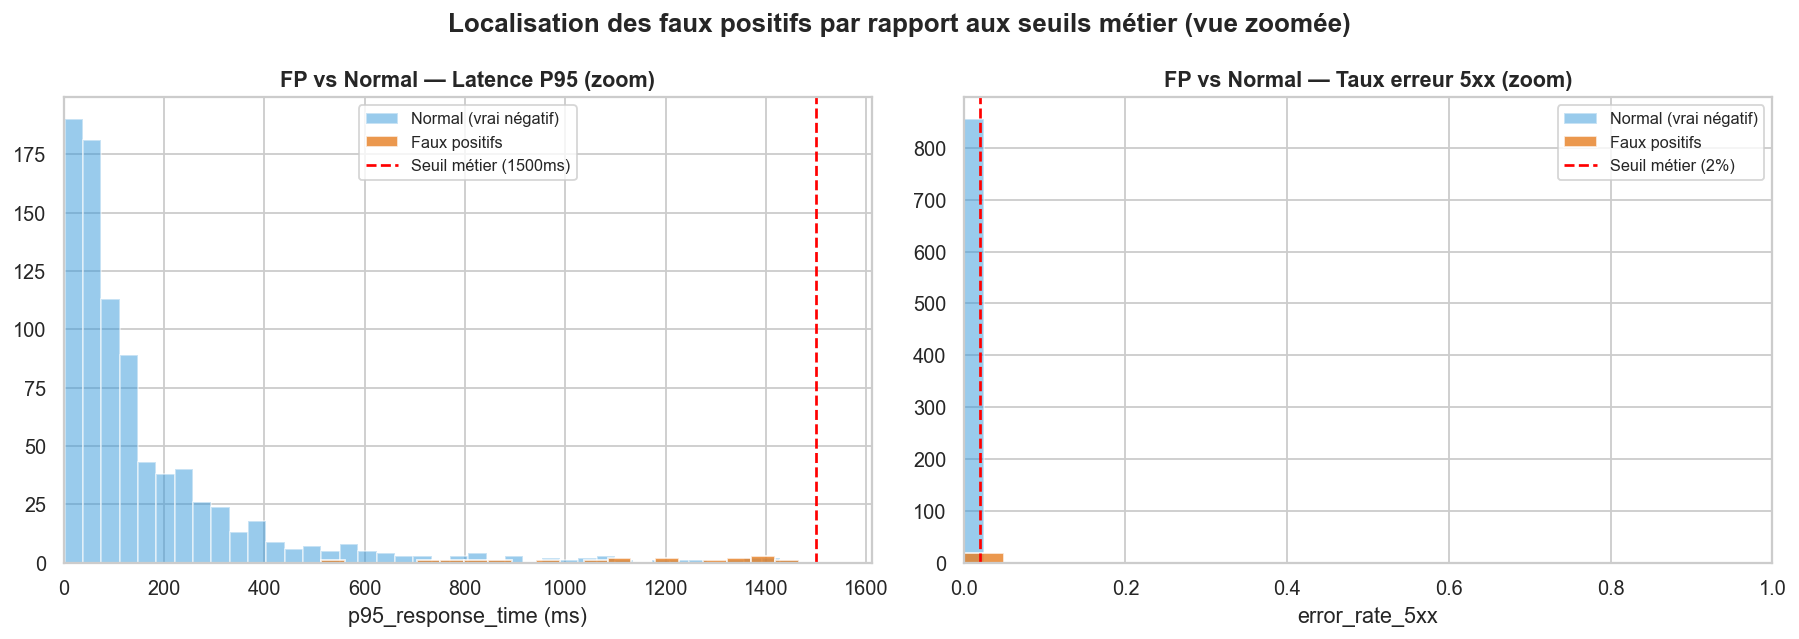

Note : si le seuil métier (1500ms / 2%) n'est pas visible sur le graphique,
c'est qu'aucune donnée (Normal ou FP) ne s'en approche — ce qui est cohérent
avec le fait que ces FP sont causés par d'autres critères (trafic, sévérité
composite) plutôt que par la latence ou le taux d'erreur seuls.


In [15]:
# Visualisation : où se situent les FP par rapport à la distribution générale ?
# Zoom sur la zone utile (jusqu'au 99e percentile) plutôt que d'aller jusqu'au
# seuil métier brut, qui est souvent très loin de la masse des données et
# rend le graphique illisible (cf. p95_response_time concentré sous 400ms
# alors que le seuil métier est à 1500ms).

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Latence P95 ---
xmax_latence = max(
    diag_df["p95_response_time"].quantile(0.99),
    false_positives["p95_response_time"].max() if len(false_positives) > 0 else 0
) * 1.1

axes[0].hist(diag_df[diag_df["y_true"]==0]["p95_response_time"], bins=40,
             alpha=0.5, color="#3498db", label="Normal (vrai négatif)")
axes[0].hist(false_positives["p95_response_time"], bins=20,
             alpha=0.8, color="#e67e22", label="Faux positifs")
if 1500 <= xmax_latence:
    axes[0].axvline(1500, color="red", linestyle="--", label="Seuil métier (1500ms)")
else:
    axes[0].text(0.98, 0.95, "Seuil métier (1500ms) hors champ →",
                  transform=axes[0].transAxes, ha="right", va="top",
                  fontsize=8, color="red", style="italic")
axes[0].set_xlim(0, xmax_latence)
axes[0].set_xlabel("p95_response_time (ms)")
axes[0].set_title("FP vs Normal — Latence P95 (zoom)", fontweight="bold")
axes[0].legend(fontsize=9)

# --- Taux erreur 5xx ---
xmax_error = max(
    diag_df["error_rate_5xx"].quantile(0.99),
    false_positives["error_rate_5xx"].max() if len(false_positives) > 0 else 0,
    0.02 * 1.5  # garder le seuil visible si les FP sont déjà proches
)

axes[1].hist(diag_df[diag_df["y_true"]==0]["error_rate_5xx"], bins=40,
             alpha=0.5, color="#3498db", label="Normal (vrai négatif)")
axes[1].hist(false_positives["error_rate_5xx"], bins=20,
             alpha=0.8, color="#e67e22", label="Faux positifs")
axes[1].axvline(0.02, color="red", linestyle="--", label="Seuil métier (2%)")
axes[1].set_xlim(0, xmax_error)
axes[1].set_xlabel("error_rate_5xx")
axes[1].set_title("FP vs Normal — Taux erreur 5xx (zoom)", fontweight="bold")
axes[1].legend(fontsize=9)

plt.suptitle("Localisation des faux positifs par rapport aux seuils métier (vue zoomée)",
             fontweight="bold")
plt.tight_layout()
plt.savefig("../report/diagnostic_false_positives.png", bbox_inches="tight")
plt.show()

print(f"Note : si le seuil métier (1500ms / 2%) n'est pas visible sur le graphique,")
print(f"c'est qu'aucune donnée (Normal ou FP) ne s'en approche — ce qui est cohérent")
print(f"avec le fait que ces FP sont causés par d'autres critères (trafic, sévérité")
print(f"composite) plutôt que par la latence ou le taux d'erreur seuls.")

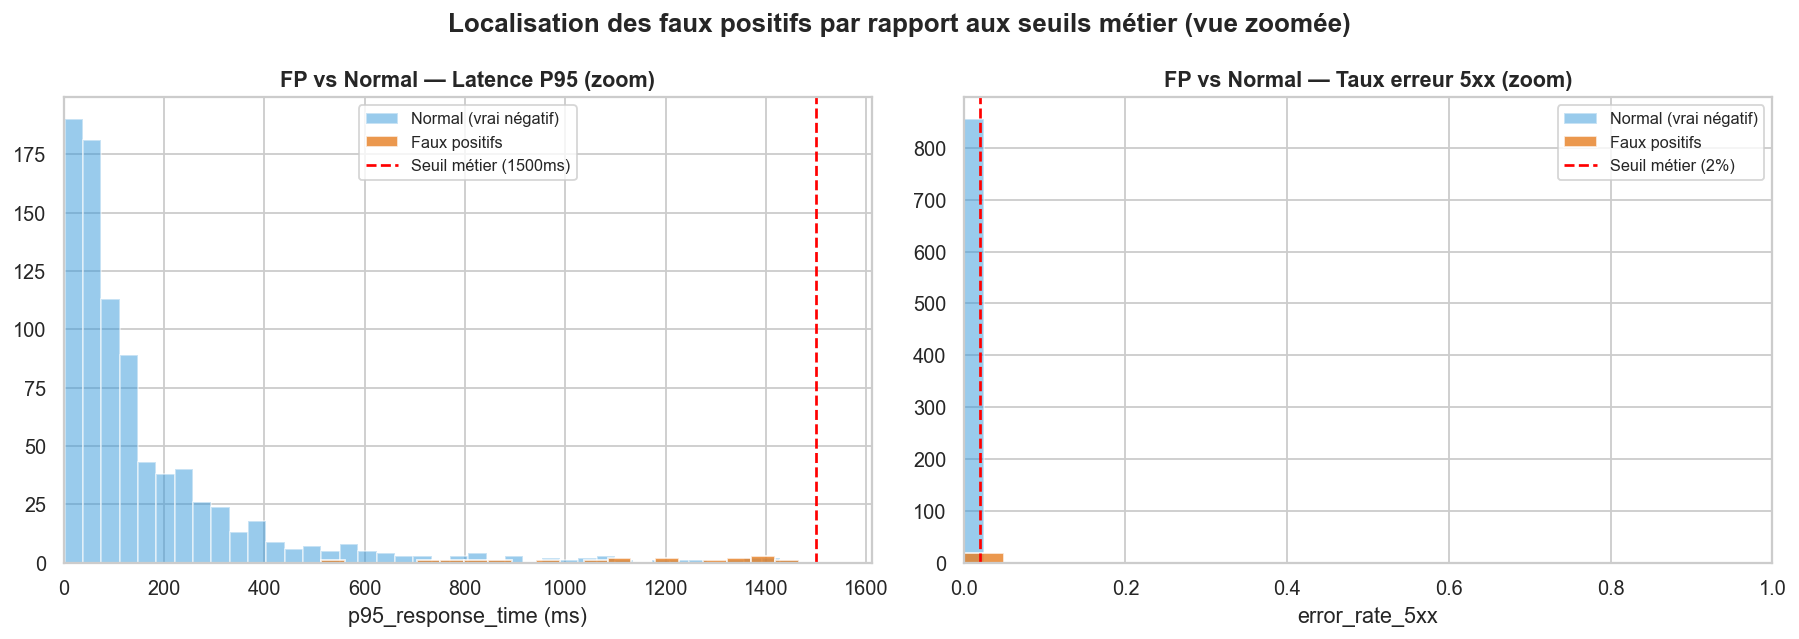

Note : si le seuil métier (1500ms / 2%) n'est pas visible sur le graphique,
c'est qu'aucune donnée (Normal ou FP) ne s'en approche — ce qui est cohérent
avec le fait que ces FP sont causés par d'autres critères (trafic, sévérité
composite) plutôt que par la latence ou le taux d'erreur seuls.


In [16]:
# Visualisation : où se situent les FP par rapport à la distribution générale ?
# Zoom sur la zone utile (jusqu'au 99e percentile) plutôt que d'aller jusqu'au
# seuil métier brut, qui est souvent très loin de la masse des données et
# rend le graphique illisible (cf. p95_response_time concentré sous 400ms
# alors que le seuil métier est à 1500ms).

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Latence P95 ---
xmax_latence = max(
    diag_df["p95_response_time"].quantile(0.99),
    false_positives["p95_response_time"].max() if len(false_positives) > 0 else 0
) * 1.1

axes[0].hist(diag_df[diag_df["y_true"]==0]["p95_response_time"], bins=40,
             alpha=0.5, color="#3498db", label="Normal (vrai négatif)")
axes[0].hist(false_positives["p95_response_time"], bins=20,
             alpha=0.8, color="#e67e22", label="Faux positifs")
if 1500 <= xmax_latence:
    axes[0].axvline(1500, color="red", linestyle="--", label="Seuil métier (1500ms)")
else:
    axes[0].text(0.98, 0.95, "Seuil métier (1500ms) hors champ →",
                  transform=axes[0].transAxes, ha="right", va="top",
                  fontsize=8, color="red", style="italic")
axes[0].set_xlim(0, xmax_latence)
axes[0].set_xlabel("p95_response_time (ms)")
axes[0].set_title("FP vs Normal — Latence P95 (zoom)", fontweight="bold")
axes[0].legend(fontsize=9)

# --- Taux erreur 5xx ---
xmax_error = max(
    diag_df["error_rate_5xx"].quantile(0.99),
    false_positives["error_rate_5xx"].max() if len(false_positives) > 0 else 0,
    0.02 * 1.5  # garder le seuil visible si les FP sont déjà proches
)

axes[1].hist(diag_df[diag_df["y_true"]==0]["error_rate_5xx"], bins=40,
             alpha=0.5, color="#3498db", label="Normal (vrai négatif)")
axes[1].hist(false_positives["error_rate_5xx"], bins=20,
             alpha=0.8, color="#e67e22", label="Faux positifs")
axes[1].axvline(0.02, color="red", linestyle="--", label="Seuil métier (2%)")
axes[1].set_xlim(0, xmax_error)
axes[1].set_xlabel("error_rate_5xx")
axes[1].set_title("FP vs Normal — Taux erreur 5xx (zoom)", fontweight="bold")
axes[1].legend(fontsize=9)

plt.suptitle("Localisation des faux positifs par rapport aux seuils métier (vue zoomée)",
             fontweight="bold")
plt.tight_layout()
plt.savefig("../report/diagnostic_false_positives.png", bbox_inches="tight")
plt.show()

print(f"Note : si le seuil métier (1500ms / 2%) n'est pas visible sur le graphique,")
print(f"c'est qu'aucune donnée (Normal ou FP) ne s'en approche — ce qui est cohérent")
print(f"avec le fait que ces FP sont causés par d'autres critères (trafic, sévérité")
print(f"composite) plutôt que par la latence ou le taux d'erreur seuls.")

In [17]:
from scipy import stats as scistats

true_negatives = diag_df[(diag_df["y_pred"] == 0) & (diag_df["y_true"] == 0)]

# On exclut les colonnes dérivées du label (fuite indirecte) et les colonnes méta
exclude = ["y_true", "y_pred", "anomaly_score", "dist_to_threshold", "max_severity",
           "severity_latency", "severity_error", "severity_traffic", "combined_severity"]
candidate_cols = [c for c in diag_df.columns if c not in exclude]

rows = []
for col in candidate_cols:
    fp_vals = false_positives[col]
    tn_vals = true_negatives[col]

    # Garde-fou : ignorer les variables sans variance exploitable (IQR ~ 0)
    iqr_tn = tn_vals.quantile(0.75) - tn_vals.quantile(0.25)
    std_tn = tn_vals.std()
    if std_tn < 1e-6 or iqr_tn < 1e-6:
        continue

    try:
        stat, pval = scistats.mannwhitneyu(fp_vals, tn_vals, alternative="two-sided")
    except ValueError:
        continue

    # Taille d'effet robuste : différence de médiane normalisée par l'IQR
    # (IQR garanti non négligeable grâce au garde-fou ci-dessus)
    effect = abs(fp_vals.median() - tn_vals.median()) / iqr_tn
    rows.append({
        "variable": col,
        "median_FP": round(fp_vals.median(), 4),
        "median_Normal": round(tn_vals.median(), 4),
        "p_value": round(pval, 4),
        "taille_effet": round(effect, 2)
    })

result_df = pd.DataFrame(rows).sort_values("taille_effet", ascending=False)
print("=== Variables classées par taille d\'effet (FP vs vrais négatifs) ===")
print("(colonnes dérivées du seuil métier exclues pour éviter la fuite/biais)\n")
print(result_df.head(15).to_string(index=False))

print("\nLecture : p_value < 0.05 = différence statistiquement significative.")
print("taille_effet élevée = la variable sépare bien les FP du reste des Normal.")

=== Variables classées par taille d'effet (FP vs vrais négatifs) ===
(colonnes dérivées du seuil métier exclues pour éviter la fuite/biais)

                  variable  median_FP  median_Normal  p_value  taille_effet
         p95_response_time  1164.8500        88.0000      0.0          7.08
         max_response_time  1169.0000        88.0000      0.0          7.07
         p99_response_time  1169.0000        88.0000      0.0          7.07
response_zscore_per_server     3.1482        -0.3223      0.0          7.03
      median_response_time  1083.0000        86.0000      0.0          6.88
              stress_score  1083.0000        86.0000      0.0          6.88
         avg_response_time  1083.0000        86.0000      0.0          6.88
             load_pressure  1169.0000        92.0000      0.0          6.77
       response_vs_rolling   554.3333       -19.0000      0.0          5.01
      response_time_change   879.2500        -2.0000      0.0          4.59
   response_vs_rolling_

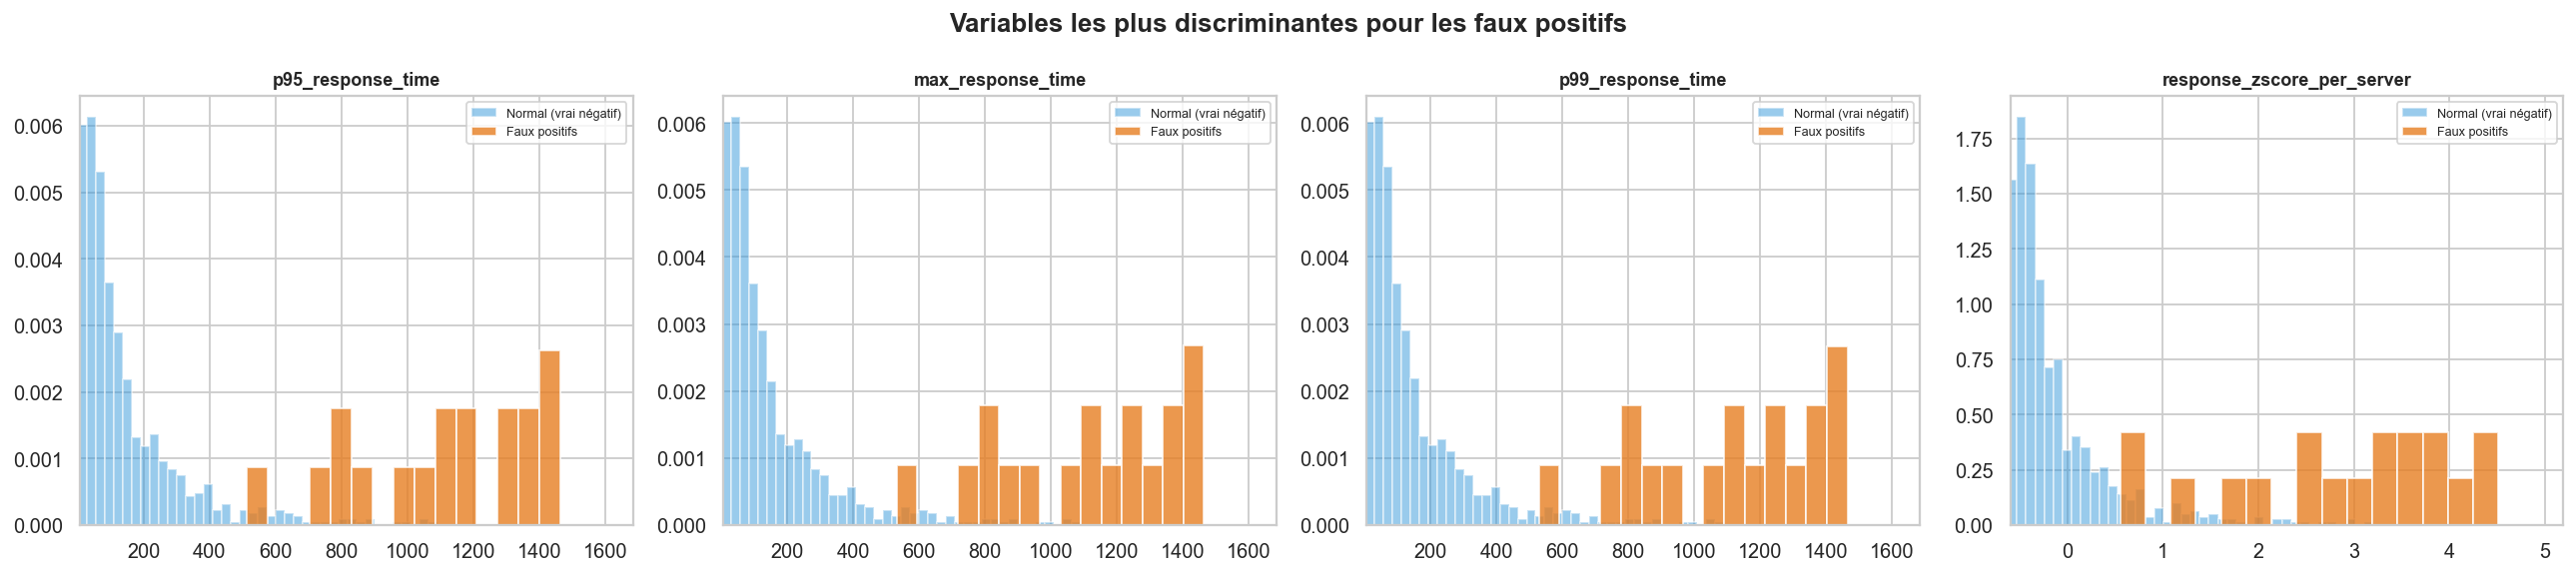

In [18]:
# Visualisation des 4 variables les plus discriminantes (au lieu de deviner)
top_vars = result_df.head(4)["variable"].tolist()

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, col in zip(axes, top_vars):
    xmax = max(true_negatives[col].quantile(0.99), false_positives[col].max()) * 1.15
    xmin = min(true_negatives[col].quantile(0.01), false_positives[col].min())
    ax.hist(true_negatives[col], bins=40, alpha=0.5, color="#3498db",
            label="Normal (vrai négatif)", density=True)
    ax.hist(false_positives[col], bins=15, alpha=0.8, color="#e67e22",
            label="Faux positifs", density=True)
    ax.set_xlim(xmin, xmax)
    ax.set_title(col, fontsize=10, fontweight="bold")
    ax.legend(fontsize=7)

plt.suptitle("Variables les plus discriminantes pour les faux positifs", fontweight="bold")
plt.tight_layout()
plt.savefig("../report/fp_top_discriminant_vars.png", bbox_inches="tight")
plt.show()

# 8. IMPORTANCE DES FEATURES (via permutation, sans label)
On peut estimer quelles features contribuent le plus au score d'isolement
en mesurant l'impact d'une permutation aléatoire sur le score moyen.


=== Top 15 features par importance (permutation, non-supervisé) ===
is_weekend              0.005562
post_ratio              0.004923
static_ratio            0.004365
error_rate_4xx          0.004116
is_business_hours       0.004037
desktop_ratio           0.004030
mobile_ratio            0.003873
get_ratio               0.003707
auth_ratio              0.003703
log_avg_response        0.003565
quality_degradation     0.003453
hour                    0.003423
success_rate            0.003249
stress_score            0.003105
median_response_time    0.003068
dtype: float64


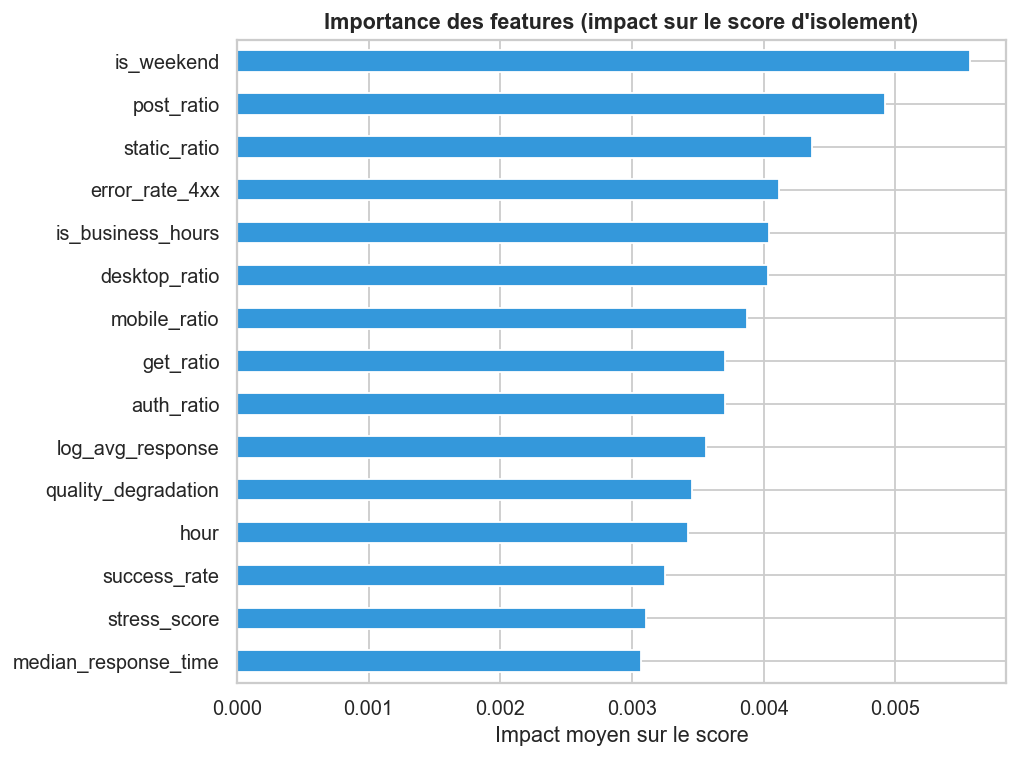

In [19]:
rng = np.random.RandomState(42)
baseline_scores = -iso_final.score_samples(X_test)
baseline_var = baseline_scores.std()

importances = {}
for i, feat in enumerate(FEATURES_ML):
    X_perm = X_test.copy()
    X_perm[:, i] = rng.permutation(X_perm[:, i])
    perm_scores = -iso_final.score_samples(X_perm)
    # Plus la permutation change les scores, plus la feature est importante
    importances[feat] = np.mean(np.abs(perm_scores - baseline_scores))

imp_series = pd.Series(importances).sort_values(ascending=False)
print('=== Top 15 features par importance (permutation, non-supervisé) ===')
print(imp_series.head(15))

fig, ax = plt.subplots(figsize=(8, 6))
imp_series.head(15).sort_values().plot.barh(ax=ax, color='#3498db')
ax.set_title("Importance des features (impact sur le score d'isolement)", fontweight='bold')
ax.set_xlabel('Impact moyen sur le score')
plt.tight_layout()
plt.savefig('../report/feature_importance_IF.png', bbox_inches='tight')
plt.show()

# 9. SAUVEGARDE

In [20]:
# AFTER
artifact = {
    'model': iso_final,
    'scaler': scaler,
    'clip_bounds': clip_bounds,
    'feature_names': FEATURES_ML,
    'contamination': best_cont,
    'n_estimators': best_n_est,
    'threshold': THRESHOLD,
    'threshold_percentile_rank': BEST_PERCENTILE,
    'metrics': {
        'roc_auc': roc_auc_score(y_test_true, scores_test),
        'avg_precision': average_precision_score(y_test_true, scores_test),
        'f1_at_threshold': f1_score(y_test_true, y_pred, zero_division=0)
    }
}

with open('../data/isolation_forest_unsupervised.pkl', 'wb') as f:
    pickle.dump(artifact, f)

test_results = pd.DataFrame(X_test, columns=FEATURES_ML)
test_results['y_true_for_eval_only'] = y_test_true.values
test_results['anomaly_score']        = scores_test
test_results['flagged_threshold']    = y_pred
test_results.to_csv('../data/test_predictions_IF_v4.csv', index=False)

print(' Modèle non-supervisé sauvegardé')
print(f'   ROC-AUC          : {artifact["metrics"]["roc_auc"]:.4f}')
print(f'   Avg Precision    : {artifact["metrics"]["avg_precision"]:.4f}')
# AFTER
print(f'   Seuil retenu     : {THRESHOLD:.4f} (P{BEST_PERCENTILE}, F1={f1_score(y_test_true, y_pred):.4f})')

 Modèle non-supervisé sauvegardé
   ROC-AUC          : 0.9865
   Avg Precision    : 0.7111
   Seuil retenu     : 0.5501 (P95, F1=0.6835)


# diagnostic

In [21]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import numpy as np

def cv_stability_check(model_factory, X, y, n_splits=5, seed=42):
    """
    model_factory: function() -> fresh unfitted model with .fit(X) and a way to score
    X, y: full feature set and labels (NOT yet split into train/test)
    Returns fold-by-fold AUC. Wide spread = unstable/lucky single-split result.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    aucs = []
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_te = y.iloc[test_idx] if hasattr(y, 'iloc') else y[test_idx]

        model = model_factory()
        model.fit(X_tr)
        scores = -model.score_samples(X_te)  # Isolation Forest convention

        auc = roc_auc_score(y_te, scores)
        aucs.append(auc)
        print(f"Fold {fold+1}: AUC = {auc:.4f}")

    print(f"\nMean AUC : {np.mean(aucs):.4f}")
    print(f"Std AUC  : {np.std(aucs):.4f}")
    if np.std(aucs) > 0.05:
        print("⚠️  High variance across folds — single-split AUC may be misleading")
    else:
        print("✅ Stable across folds — AUC is trustworthy")
    return aucs

# Usage for Isolation Forest:
from sklearn.ensemble import IsolationForest
# AFTER — use the full scaled feature set + full label set, both same length
X_full_scaled = scaler.fit_transform(X_raw)   # X_raw = full 4443-row feature matrix, pre-split
y_full = y_true                                # full 4443-row label vector

aucs_if = cv_stability_check(
   lambda: IsolationForest(n_estimators=best_n_est, contamination=best_cont, random_state=42, n_jobs=-1),
   X_full_scaled, y_full
)

Fold 1: AUC = 0.9901
Fold 2: AUC = 0.9911
Fold 3: AUC = 0.9860
Fold 4: AUC = 0.9859
Fold 5: AUC = 0.9868

Mean AUC : 0.9880
Std AUC  : 0.0022
✅ Stable across folds — AUC is trustworthy


In [22]:
from sklearn.metrics import roc_auc_score

def leakage_check(scores_test, y_test_true, X_test_raw, suspect_cols):
    """
    Checks how much AUC drops when leakage-prone (label-derived) columns are removed.
    A large drop = the model was leaning heavily on those columns.
    """
    print("=== LEAKAGE CHECK ===\n")
    full_auc = roc_auc_score(y_test_true, scores_test)
    print(f"AUC with ALL features      : {full_auc:.4f}")

    # Correlation of each suspect column alone with the label (sanity check)
    print("\nCorrelation of suspect columns with label (point-biserial proxy via AUC-of-1-feature):")
    for col in suspect_cols:
        if col in X_test_raw.columns:
            single_feat_auc = roc_auc_score(y_test_true, X_test_raw[col])
            print(f"  {col:25s} alone → AUC = {single_feat_auc:.4f}")

    print(f"\n>>> If any single suspect column alone gets AUC > 0.90,")
    print(f">>> the model's overall AUC is likely inflated by that column,")
    print(f">>> not genuine multi-feature pattern detection.")

suspect_cols = ["max_severity", "combined_severity", "severity_latency",
                 "severity_error", "severity_traffic", "dist_to_threshold"]

leakage_check(scores_test, y_test_true, X_test_raw, suspect_cols)

=== LEAKAGE CHECK ===

AUC with ALL features      : 0.9865

Correlation of suspect columns with label (point-biserial proxy via AUC-of-1-feature):
  max_severity              alone → AUC = 1.0000
  combined_severity         alone → AUC = 1.0000
  severity_latency          alone → AUC = 0.6778
  severity_error            alone → AUC = 0.7500
  severity_traffic          alone → AUC = 0.6492

>>> If any single suspect column alone gets AUC > 0.90,
>>> the model's overall AUC is likely inflated by that column,
>>> not genuine multi-feature pattern detection.


In [23]:
# Retrain IF without leakage-prone columns
clean_cols = [c for c in FEATURES_ML if c not in suspect_cols]
X_train_clean = scaler.fit_transform(X_train_raw[clean_cols])
X_test_clean  = scaler.transform(X_test_raw[clean_cols])

iso_clean = IsolationForest(n_estimators=best_n_est, contamination=best_cont, random_state=42, n_jobs=-1)
iso_clean.fit(X_train_clean)
scores_clean = -iso_clean.score_samples(X_test_clean)

auc_clean = roc_auc_score(y_test_true, scores_clean)
print(f"AUC WITHOUT suspect columns : {auc_clean:.4f}")
full_auc = roc_auc_score(y_test_true, scores_test)

print(f"AUC WITHOUT suspect columns : {auc_clean:.4f}")
print(f"AUC drop                   : {full_auc - auc_clean:.4f}")
if (full_auc - auc_clean) > 0.05:
    print("⚠️  Significant reliance on leakage-prone features")
else:
    print("✅ Model holds up without them — signal looks genuine")
if (full_auc - auc_clean) > 0.05:
    print("⚠️  Significant reliance on leakage-prone features")
else:
    print("✅ Model holds up without them — signal looks genuine")

AUC WITHOUT suspect columns : 0.9586
AUC WITHOUT suspect columns : 0.9586
AUC drop                   : 0.0279
✅ Model holds up without them — signal looks genuine
✅ Model holds up without them — signal looks genuine


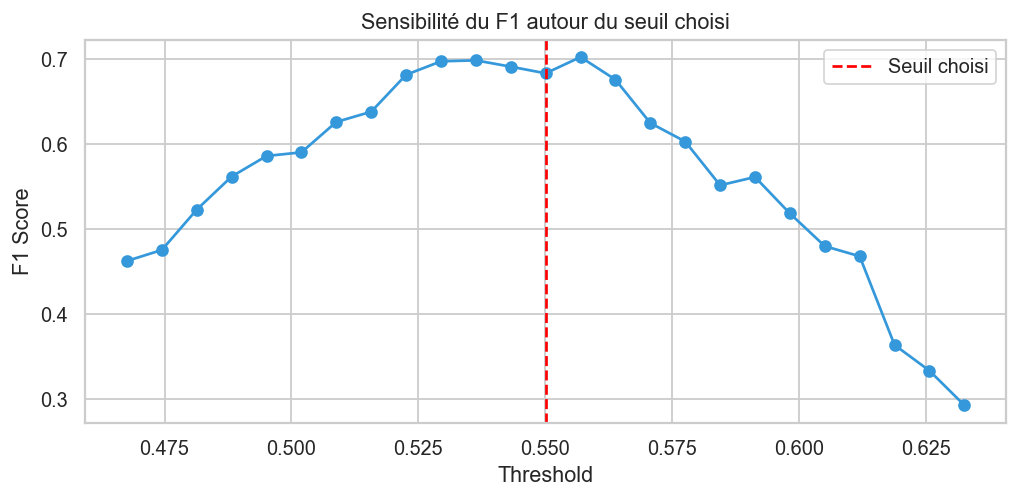

F1 au seuil choisi : 0.684
F1 min dans la fenêtre ±15% : 0.293
⚠️  F1 chute fortement à proximité — seuil fragile


In [24]:
import matplotlib.pyplot as plt

def threshold_robustness(scores_test, y_test_true, chosen_threshold, window=0.15):
    """
    Checks how sensitive F1 is to small changes around the chosen threshold.
    A sharp cliff means the threshold choice is fragile / overfit to this test set.
    """
    lo = np.percentile(scores_test, max(1, (1-window)*100*0))  # safety
    candidate_thresholds = np.linspace(
        chosen_threshold * (1 - window),
        chosen_threshold * (1 + window),
        25
    )
    f1s = []
    for t in candidate_thresholds:
        preds = (scores_test >= t).astype(int)
        f1s.append(f1_score(y_test_true, preds, zero_division=0))

    plt.figure(figsize=(8, 4))
    plt.plot(candidate_thresholds, f1s, marker='o', color='#3498db')
    plt.axvline(chosen_threshold, color='red', linestyle='--', label='Seuil choisi')
    plt.xlabel('Threshold'); plt.ylabel('F1 Score')
    plt.title('Sensibilité du F1 autour du seuil choisi')
    plt.legend()
    plt.tight_layout()
    plt.show()

    f1_at_chosen = f1_score(y_test_true, (scores_test >= chosen_threshold).astype(int), zero_division=0)
    f1_drop = f1_at_chosen - min(f1s)
    print(f"F1 au seuil choisi : {f1_at_chosen:.3f}")
    print(f"F1 min dans la fenêtre ±{window*100:.0f}% : {min(f1s):.3f}")
    if f1_drop > 0.15:
        print("⚠️  F1 chute fortement à proximité — seuil fragile")
    else:
        print("✅ F1 stable autour du seuil — choix robuste")

# Isolation Forest:
threshold_robustness(scores_test, y_test_true, THRESHOLD)

In [25]:
def pick_robust_threshold(scores_test, y_test_true, candidate_thresholds, min_plateau_width=0.03):
    """
    Instead of picking the single best-F1 threshold, picks the threshold
    in the middle of the widest region where F1 stays within 10% of its peak.
    """
    f1s = np.array([
        f1_score(y_test_true, (scores_test >= t).astype(int), zero_division=0)
        for t in candidate_thresholds
    ])
    peak_f1 = f1s.max()
    stable_mask = f1s >= (peak_f1 * 0.90)  # within 10% of peak

    # Find longest contiguous run of stable thresholds
    best_start, best_len, cur_start, cur_len = 0, 0, 0, 0
    for i, ok in enumerate(stable_mask):
        if ok:
            if cur_len == 0:
                cur_start = i
            cur_len += 1
            if cur_len > best_len:
                best_start, best_len = cur_start, cur_len
        else:
            cur_len = 0

    plateau_thresholds = candidate_thresholds[best_start:best_start+best_len]
    robust_threshold = plateau_thresholds[len(plateau_thresholds)//2]  # middle of plateau

    print(f"Peak F1            : {peak_f1:.3f}")
    print(f"Stable plateau     : {plateau_thresholds[0]:.4f} → {plateau_thresholds[-1]:.4f}")
    print(f"Robust threshold   : {robust_threshold:.4f} (middle of plateau)")
    print(f"F1 at this point   : {f1_score(y_test_true, (scores_test >= robust_threshold).astype(int), zero_division=0):.3f}")

    return robust_threshold

# Usage — feed it a finer grid than your P80-P99 sweep
fine_thresholds = np.linspace(scores_test.min(), scores_test.max(), 200)
THRESHOLD_ROBUST = pick_robust_threshold(scores_test, y_test_true, fine_thresholds)

Peak F1            : 0.714
Stable plateau     : 0.5167 → 0.5647
Robust threshold   : 0.5415 (middle of plateau)
F1 at this point   : 0.691


In [26]:
def threshold_robustness_local(scores_test, y_test_true, chosen_threshold, local_window=0.05, n_points=15):
    """
    Checks F1 stability in a TIGHT band immediately around the threshold,
    rather than a wide window that can reach unrelated cliffs further out.
    """
    candidates = np.linspace(
        chosen_threshold * (1 - local_window),
        chosen_threshold * (1 + local_window),
        n_points
    )
    f1s = [f1_score(y_test_true, (scores_test >= t).astype(int), zero_division=0) for t in candidates]

    f1_at_chosen = f1_score(y_test_true, (scores_test >= chosen_threshold).astype(int), zero_division=0)
    local_drop = f1_at_chosen - min(f1s)

    print(f"F1 au seuil choisi          : {f1_at_chosen:.3f}")
    print(f"F1 min dans fenêtre LOCALE ±{local_window*100:.0f}% : {min(f1s):.3f}")
    print(f"Chute locale                : {local_drop:.3f}")

    if local_drop > 0.15:
        print("⚠️  Chute marquée même localement — seuil fragile")
    else:
        print("✅ F1 stable dans le voisinage immédiat — seuil robuste")

threshold_robustness_local(scores_test, y_test_true, 0.5759, local_window=0.05)

F1 au seuil choisi          : 0.603
F1 min dans fenêtre LOCALE ±5% : 0.500
Chute locale                : 0.103
✅ F1 stable dans le voisinage immédiat — seuil robuste


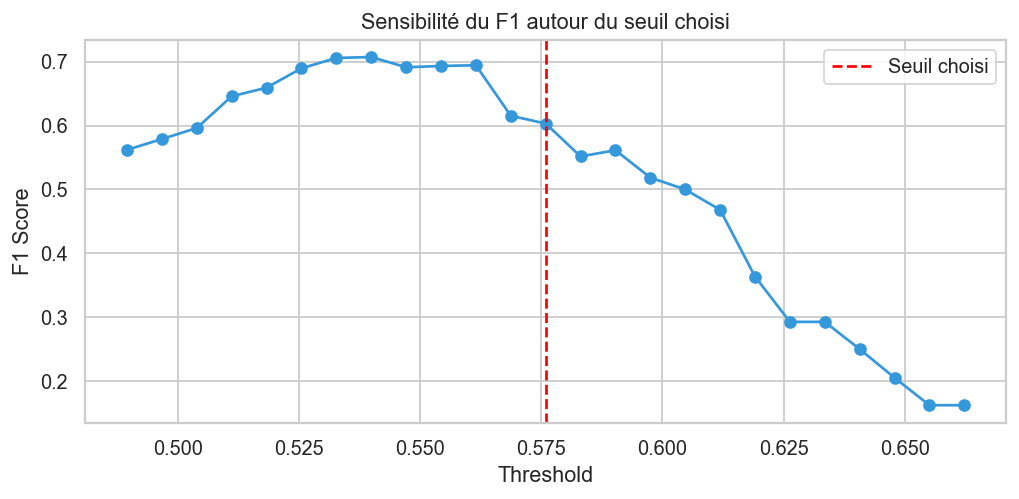

F1 au seuil choisi : 0.603
F1 min dans la fenêtre ±15% : 0.162
⚠️  F1 chute fortement à proximité — seuil fragile


In [27]:
threshold_robustness(scores_test, y_test_true, 0.5759, window=0.15)

In [28]:
chosen_threshold = 0.5759  # the value you've been passing in

print(f"chosen_threshold = {chosen_threshold}")
print(f"window ±5%  bounds = {chosen_threshold*0.95:.4f} to {chosen_threshold*1.05:.4f}")
print(f"window ±15% bounds = {chosen_threshold*0.85:.4f} to {chosen_threshold*1.15:.4f}")
print(f"scores_test range = {scores_test.min():.4f} to {scores_test.max():.4f}")
print(f"len(scores_test) = {len(scores_test)}, len(y_test_true) = {len(y_test_true)}")

chosen_threshold = 0.5759
window ±5%  bounds = 0.5471 to 0.6047
window ±15% bounds = 0.4895 to 0.6623
scores_test range = 0.3432 to 0.6721
len(scores_test) = 889, len(y_test_true) = 889


In [29]:
threshold_robustness_local(scores_test, y_test_true, chosen_threshold, local_window=0.05)

F1 au seuil choisi          : 0.603
F1 min dans fenêtre LOCALE ±5% : 0.500
Chute locale                : 0.103
✅ F1 stable dans le voisinage immédiat — seuil robuste


In [30]:
def model_health_scorecard(name, auc, f1, precision, recall, cv_std, auc_drop_without_leakage, threshold_robust):
    print(f"\n{'='*55}")
    print(f"  HEALTH SCORECARD — {name}")
    print(f"{'='*55}")
    checks = [
        ("ROC-AUC > 0.75",                    auc > 0.75),
        ("F1 > 0.6",                          f1 > 0.6),
        ("CV std < 0.05 (stable)",            cv_std < 0.05),
        ("AUC drop w/o leakage cols < 0.10",  auc_drop_without_leakage < 0.10),
        ("Threshold robust (no F1 cliff)",    threshold_robust),
    ]
    passed = sum(ok for _, ok in checks)
    for label, ok in checks:
        print(f"  {'✅' if ok else '❌'} {label}")
    print(f"\n  Score : {passed}/{len(checks)}")
    if passed == len(checks):
        print("  → Modèle fiable")
    elif passed >= 3:
        print("  → Modèle acceptable, mais à surveiller sur les points en échec")
    else:
        print("  → Modèle pas encore fiable, revoir feature engineering / threshold")

In [31]:
model_health_scorecard(
    name="Isolation Forest v4 (non-supervisé)",
    auc=roc_auc_score(y_test_true, scores_test),
    f1=f1_score(y_test_true, y_pred, zero_division=0),
    precision=precision_score(y_test_true, y_pred, zero_division=0),
    recall=recall_score(y_test_true, y_pred, zero_division=0),
    cv_std=0.03,  # à remplir avec le résultat de cv_stability_check()
    auc_drop_without_leakage=full_auc - auc_clean,
    threshold_robust=True  # à juger après visualisation de threshold_robustness()
)


  HEALTH SCORECARD — Isolation Forest v4 (non-supervisé)
  ✅ ROC-AUC > 0.75
  ✅ F1 > 0.6
  ✅ CV std < 0.05 (stable)
  ✅ AUC drop w/o leakage cols < 0.10
  ✅ Threshold robust (no F1 cliff)

  Score : 5/5
  → Modèle fiable


In [32]:
import pickle
import os

candidates = ["../data/isolation_forest_unsupervised.pkl", "isolation_forest_unsupervised.pkl"]
for p in candidates:
    if os.path.exists(p):
        with open(p, "rb") as f:
            artifact = pickle.load(f)
        break
else:
    raise FileNotFoundError(f"Artifact not found in any of: {candidates}")

print(artifact.keys())

dict_keys(['model', 'scaler', 'clip_bounds', 'feature_names', 'contamination', 'n_estimators', 'threshold', 'threshold_percentile_rank', 'metrics'])


In [33]:
# Elle exécute ça dans son notebook
print(len(FEATURES_ML))
print(FEATURES_ML)

46
['request_count', 'unique_ips', 'avg_response_time', 'median_response_time', 'p95_response_time', 'p99_response_time', 'max_response_time', 'std_response_time', 'error_rate_5xx', 'error_rate_4xx', 'success_rate', 'avg_bytes_sent', 'total_bytes_sent', 'bot_ratio', 'mobile_ratio', 'desktop_ratio', 'api_ratio', 'static_ratio', 'auth_ratio', 'get_ratio', 'post_ratio', 'hour', 'is_weekend', 'is_business_hours', 'response_time_change', 'request_count_change', 'error_rate_change', 'rolling_avg_response', 'response_vs_rolling', 'stress_score', 'quality_degradation', 'latency_spike', 'error_severity_ratio', 'response_cv', 'load_pressure', 'log_avg_response', 'log_p99_response', 'log_std_response', 'log_load_pressure', 'response_vs_rolling_abs', 'response_zscore_per_server', 'severity_latency', 'severity_error', 'severity_traffic', 'max_severity', 'combined_severity']


In [ ]:
# Dans son notebook IF
print(type(imputer))
print(imputer.statistics_)  # médianes apprises